<a href="https://colab.research.google.com/github/dldustj0715/machine_learning/blob/main/week04/%EA%B8%B0%EA%B3%84%ED%95%99%EC%8A%B5_0928_Auto_MPG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# ============================================================
# Auto MPG Dataset
# Logistic Regression을 이용한 연비 다중분류
#
# mpg를 3개 구간으로 나누어
# low / medium / high로 classification
# ============================================================


# 1. 라이브러리 불러오기
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


# ============================================================
# 2. 데이터 불러오기
# ============================================================

df = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/auto-mpg.data',
    sep=r'\s+',
    header=None,
    na_values='?'
)


# column 이름 설정
df.columns = [
    'mpg',
    'cylinders',
    'displacement',
    'horsepower',
    'weight',
    'acceleration',
    'model_year',
    'origin',
    'car_name'
]


print("===== 데이터 확인 =====")
print(df.head())


print("\n===== 데이터 크기 =====")
print(df.shape)


print("\n===== 데이터 정보 =====")
print(df.info())



===== 데이터 확인 =====
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0  3504.0          12.0   
1  15.0          8         350.0       165.0  3693.0          11.5   
2  18.0          8         318.0       150.0  3436.0          11.0   
3  16.0          8         304.0       150.0  3433.0          12.0   
4  17.0          8         302.0       140.0  3449.0          10.5   

   model_year  origin                   car_name  
0          70       1  chevrolet chevelle malibu  
1          70       1          buick skylark 320  
2          70       1         plymouth satellite  
3          70       1              amc rebel sst  
4          70       1                ford torino  

===== 데이터 크기 =====
(398, 9)

===== 데이터 정보 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg       

In [4]:

# ============================================================
# 3. 결측값 확인 및 제거
# ============================================================

print("\n===== 결측값 확인 =====")
print(df.isnull().sum())


# horsepower의 결측값 제거
df = df.dropna()


print("\n===== 결측값 제거 후 데이터 크기 =====")
print(df.shape)





===== 결측값 확인 =====
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

===== 결측값 제거 후 데이터 크기 =====
(392, 9)


In [5]:
# ============================================================
# 4. mpg를 low / medium / high로 분류
# ============================================================

# mpg의 33%, 66% 분위수 계산
q1 = df['mpg'].quantile(1/3)
q2 = df['mpg'].quantile(2/3)


print("\n===== MPG 분류 기준 =====")
print("33% 기준:", q1)
print("66% 기준:", q2)


# mpg를 세 개의 class로 변환
def mpg_class(mpg):
    if mpg <= q1:
        return 'low'
    elif mpg <= q2:
        return 'medium'
    else:
        return 'high'


df['class'] = df['mpg'].apply(mpg_class)


print("\n===== MPG와 Class 확인 =====")
print(df[['mpg', 'class']].head(20))


print("\n===== Class 분포 =====")
print(df['class'].value_counts())





===== MPG 분류 기준 =====
33% 기준: 18.733333333333327
66% 기준: 26.933333333333326

===== MPG와 Class 확인 =====
     mpg   class
0   18.0     low
1   15.0     low
2   18.0     low
3   16.0     low
4   17.0     low
5   15.0     low
6   14.0     low
7   14.0     low
8   14.0     low
9   15.0     low
10  15.0     low
11  14.0     low
12  15.0     low
13  14.0     low
14  24.0  medium
15  22.0  medium
16  18.0     low
17  21.0  medium
18  27.0    high
19  26.0  medium

===== Class 분포 =====
class
low       131
high      131
medium    130
Name: count, dtype: int64


In [6]:
# ============================================================
# 5. X와 y 설정
# ============================================================

# car_name은 연비 분류에 사용하지 않음
# mpg는 class를 만드는 데 사용했으므로 X에서 제외

X = df[
    [
        'cylinders',
        'displacement',
        'horsepower',
        'weight',
        'acceleration',
        'model_year',
        'origin'
    ]
]

y = df['class']


print("\n===== X =====")
print(X.head())


print("\n===== y =====")
print(y.head())





===== X =====
   cylinders  displacement  horsepower  weight  acceleration  model_year  \
0          8         307.0       130.0  3504.0          12.0          70   
1          8         350.0       165.0  3693.0          11.5          70   
2          8         318.0       150.0  3436.0          11.0          70   
3          8         304.0       150.0  3433.0          12.0          70   
4          8         302.0       140.0  3449.0          10.5          70   

   origin  
0       1  
1       1  
2       1  
3       1  
4       1  

===== y =====
0    low
1    low
2    low
3    low
4    low
Name: class, dtype: object


In [7]:
# ============================================================
# 6. Class Label Encoding
# ============================================================

le = LabelEncoder()

y_encoded = le.fit_transform(y)


print("\n===== Class Label Encoding =====")
print(le.classes_)


for i, class_name in enumerate(le.classes_):
    print(class_name, "->", i)





===== Class Label Encoding =====
['high' 'low' 'medium']
high -> 0
low -> 1
medium -> 2


In [8]:
# ============================================================
# 7. Train / Test 데이터 분리
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


print("\n===== Train / Test 크기 =====")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)




===== Train / Test 크기 =====
X_train: (313, 7)
X_test : (79, 7)
y_train: (313,)
y_test : (79,)


In [9]:

# ============================================================
# 8. Logistic Regression 모델 생성 및 학습
# ============================================================

model = LogisticRegression(
    max_iter=5000
)

model.fit(X_train, y_train)




/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [10]:
# ============================================================
# 9. Test 데이터 예측
# ============================================================

y_pred = model.predict(X_test)


print("\n===== 예측 결과 =====")
print(y_pred[:20])


# 숫자를 다시 class 이름으로 변환
y_pred_label = le.inverse_transform(y_pred)


print("\n===== Class 이름으로 변환한 예측 결과 =====")
print(y_pred_label[:20])





===== 예측 결과 =====
[1 0 1 1 1 2 2 1 2 0 2 1 0 0 1 0 1 0 0 0]

===== Class 이름으로 변환한 예측 결과 =====
['low' 'high' 'low' 'low' 'low' 'medium' 'medium' 'low' 'medium' 'high'
 'medium' 'low' 'high' 'high' 'low' 'high' 'low' 'high' 'high' 'high']


In [11]:
# ============================================================
# 10. Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)


print("\n===== Accuracy =====")
print("Accuracy:", accuracy)





===== Accuracy =====
Accuracy: 0.7848101265822784


In [12]:
# ============================================================
# 11. Classification Report
# ============================================================

print("\n===== Classification Report =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=le.classes_
    )
)




===== Classification Report =====
              precision    recall  f1-score   support

        high       0.86      0.70      0.78        27
         low       0.83      0.96      0.89        26
      medium       0.67      0.69      0.68        26

    accuracy                           0.78        79
   macro avg       0.79      0.79      0.78        79
weighted avg       0.79      0.78      0.78        79




===== Confusion Matrix =====
[[19  0  8]
 [ 0 25  1]
 [ 3  5 18]]


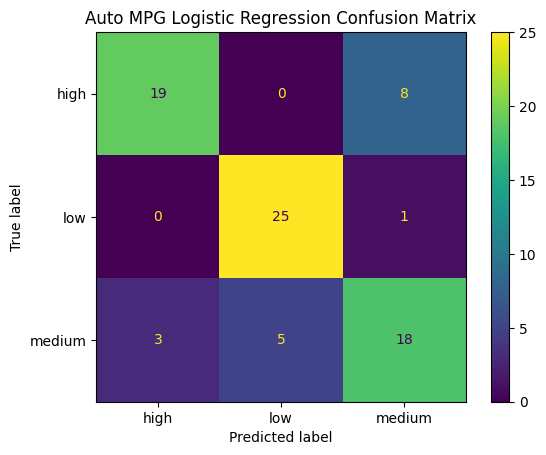

In [13]:

# ============================================================
# 12. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)


print("\n===== Confusion Matrix =====")
print(cm)


ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
).plot()


plt.title("Auto MPG Logistic Regression Confusion Matrix")
plt.show()